In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_train = pd.read_csv('../data/train_pca.csv')
df_test = pd.read_csv('../data/test_pca.csv')

In [3]:
x_train = df_train.drop(columns=['target'])
y_train = df_train['target']

In [4]:
x_test = df_test.drop(columns=['target'])
y_test = df_test['target']

In [5]:
x_train.shape

(237, 12)

In [6]:
x_test.shape

(60, 12)

In [7]:
model = LogisticRegression()
model.fit(x_train, y_train)
model.score(x_train, y_train)

0.8649789029535865

In [8]:
y_probs = model.predict_proba(x_test)[:,1]

In [9]:
y_pred = model.predict(x_test)

In [10]:
model.score(x_test, y_test)

0.85

In [11]:
print(confusion_matrix(y_test, y_pred))

[[32  4]
 [ 5 19]]


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.88        36
           1       0.83      0.79      0.81        24

    accuracy                           0.85        60
   macro avg       0.85      0.84      0.84        60
weighted avg       0.85      0.85      0.85        60



In [13]:
roc_auc = roc_auc_score(y_test, y_probs)
roc_auc

0.9513888888888888

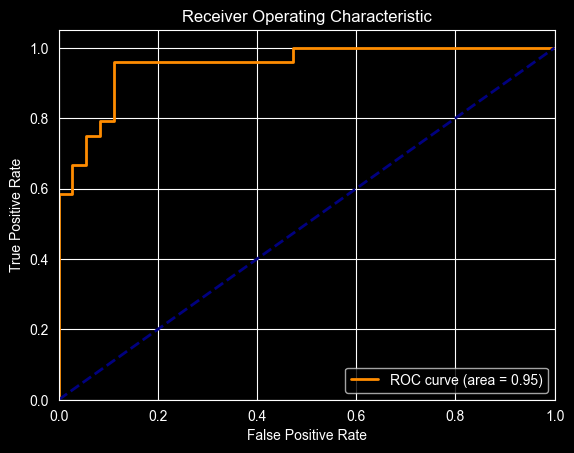

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [15]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier()
}

In [16]:
roc_auc_scores = {}

In [17]:
plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

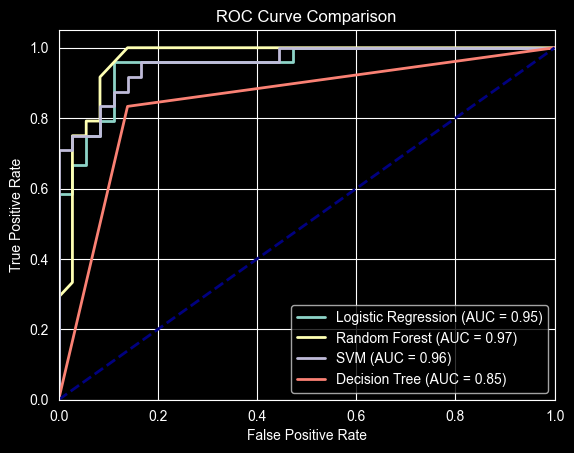

In [18]:
for name,model in models.items():
    model.fit(x_train, y_train)
    y_probs = model.predict_proba(x_test)[:,1]

    roc_auc = roc_auc_score(y_test, y_probs)
    roc_auc_scores[name] = roc_auc

    fpr, tpr, _ = roc_curve(y_test, y_probs)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()



In [19]:

for name, score in roc_auc_scores.items():
    print(f'{name}: AUC - ROC = {score:.2f}')

Logistic Regression: AUC - ROC = 0.95
Random Forest: AUC - ROC = 0.97
SVM: AUC - ROC = 0.96
Decision Tree: AUC - ROC = 0.85


In [20]:
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [21]:
rand_model = RandomForestClassifier()
rand_model.fit(x_train, y_train)
y_probs = rand_model.predict_proba(x_test)[:, 1]
y_pred = rand_model.predict(x_test)
rand_model.score(x_test, y_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
scores = cross_val_score(rand_model, x_train, y_train, cv=5, scoring='roc_auc')
print(f"Average AUC: {scores.mean():.2f}")
print(f"Stability (Std Dev): {scores.std():.2f}")


[[33  3]
 [ 4 20]]
              precision    recall  f1-score   support

           0       0.89      0.92      0.90        36
           1       0.87      0.83      0.85        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60

Average AUC: 0.89
Stability (Std Dev): 0.05


In [22]:
svc_model = SVC(probability=True)
svc_model.fit(x_train, y_train)
y_probs = svc_model.predict_proba(x_test)[:, 1]
y_pred = svc_model.predict(x_test)
svc_model.score(x_test, y_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
scores = cross_val_score(svc_model, x_train, y_train, cv=5, scoring='roc_auc')
print(f"Average AUC: {scores.mean():.2f}")
print(f"Stability (Std Dev): {scores.std():.2f}")


[[32  4]
 [ 4 20]]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        36
           1       0.83      0.83      0.83        24

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60

Average AUC: 0.88
Stability (Std Dev): 0.05


In [23]:
log_model = LogisticRegression()
log_model.fit(x_train, y_train)
# y_probs = log_model.predict_proba(x_test)[:, 1]
# y_pred = log_model.predict(x_test)
# log_model.score(x_test, y_test)
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))
# scores = cross_val_score(log_model, x_train, y_train, cv=5, scoring='roc_auc')
# print(f"Average AUC: {scores.mean():.2f}")
# print(f"Stability (Std Dev): {scores.std():.2f}")

y_probs = log_model.predict_proba(x_train)[:,1]

fpr, tpr, thresholds = roc_curve(y_train, y_probs)

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f'Best Threshold: {best_threshold:.4f}')

test_probs = log_model.predict_proba(x_test)[:, 1]

final_preds = (test_probs >= best_threshold).astype(int)

print(classification_report(y_test, final_preds))

Best Threshold: 0.4833
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        36
           1       0.83      0.83      0.83        24

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60

